# Baseline espectro-temporal sobre PASTIS-R

Este notebook responde una pregunta concreta: ¿cuanto aporta el feature
engineering espectro-temporal frente a usar las bandas satelitales crudas?
Para responderla se entrena un baseline tabular — `DummyClassifier`,
`RandomForest`, `XGBoost` — sobre dos vistas de caracteristicas de la misma
muestra de parcelas PASTIS-R:

1. **Vista completa**: las 187 estadisticas espectro-temporales por parcela
   — 17 indices espectrales (NDVI, EVI, NDWI, ...) resumidos por 9
   estadisticos cada uno, mas componentes de Fourier y descriptores de
   fenologia (inicio de crecimiento, pico, senescencia).
2. **Vista Sentinel-2 crudo**: solo las 17 columnas de media (`*_mean`),
   un proxy de "usar la banda promedio sin enriquecerla".

Comparar ambas con el mismo modelo y la misma validacion cruzada espacial
aisla el efecto del feature engineering.

## Requisitos para ejecucion end-to-end

- Subset espectro-temporal en
  `data/test_fixtures/feature_selection_subset.parquet`.
- Dependencias instaladas via `poetry install --with ml,geo`.

Si el subset no esta disponible, el notebook genera un fixture sintetico
determinista (seed=42) con la misma firma de columnas y completa la
ejecucion sin error.


## Seccion 0 — Setup

In [1]:
# Parametros papermill (celda etiquetada 'parameters').
spectral_subset_rel = 'data/test_fixtures/feature_selection_subset.parquet'
n_folds = 5
min_class_count = 3
grid_search = True
random_seed = 42
figures_dir = 'reports/baseline/spectral'

In [2]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import structlog
from IPython.display import Markdown, display

# Bootstrap sys.path para que funcione desde notebooks/baseline/.
_BOOT = Path.cwd().resolve()
for _cand in (_BOOT, *_BOOT.parents):
    if (_cand / 'pyproject.toml').is_file():
        _BOOT = _cand
        break
if str(_BOOT) not in sys.path:
    sys.path.insert(0, str(_BOOT))

from ml.utils.notebook_setup import find_repo_root
from ml.train.train_baseline import (
    BaselineConfig,
    filter_rare_classes,
    spatial_cv_evaluate,
    train_baselines,
)
from ml.eval.metrics import (
    classification_report_df,
    compute_classification_metrics,
    confusion_matrix_df,
)
from ml.eval.plots import (
    plot_class_distribution,
    plot_confusion_matrix,
    plot_feature_importance,
)
from ml.features.selection import compute_feature_importance
from ml.ingest.pastis_loader import PASTIS_R_CLASSES

REPO_ROOT = find_repo_root(Path.cwd())

pl.Config.set_tbl_formatting('ASCII_MARKDOWN')
pl.Config.set_tbl_rows(25)
pl.Config.set_fmt_str_lengths(50)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

%matplotlib inline
%load_ext autoreload
%autoreload 2

log = structlog.get_logger('baseline_spectral')

FIGURES = REPO_ROOT / figures_dir
FIGURES.mkdir(parents=True, exist_ok=True)
MLRUNS_DIR = REPO_ROOT / 'mlruns'

SPECTRAL_SUBSET = REPO_ROOT / spectral_subset_rel

display(Markdown(
    f'**Subset espectro-temporal**: `{spectral_subset_rel}` '
    f'(existe: `{SPECTRAL_SUBSET.exists()}`)'
))

**Subset espectro-temporal**: `data/test_fixtures/feature_selection_subset.parquet` (existe: `True`)

## Seccion 1 — Encuadre del problema y carga de datos

El problema es de **clasificacion multiclase**: predecir el tipo de cultivo
de una parcela a partir de un vector de estadisticas calculadas sobre su
serie temporal de imagenes satelitales. A diferencia del embedding
AlphaEarth (coordenadas latentes abstractas), aqui cada columna tiene un
significado agronomico legible: por ejemplo `NDVI_mean` es el verdor
promedio del cultivo a lo largo del anio.

Si el subset real no esta presente se genera un fixture sintetico
determinista con la misma firma de columnas, de modo que el notebook es
ejecutable end-to-end en cualquier maquina.


In [3]:
# Carga del subset espectro-temporal (real o sintetico).
_INDEX_NAMES = [
    'NDVI', 'NDWI', 'EVI', 'NDMI', 'NBR', 'MSAVI2', 'NDRE', 'MCARI',
    'CCCI', 'GCVI', 'PSRI', 'NDCI', 'FAPAR', 'LAI', 'RENDVI', 'SAVI', 'TSAVI',
]
_STATS = ['mean', 'std', 'min', 'max', 'p05', 'p25', 'p50', 'p75', 'p95']

if SPECTRAL_SUBSET.exists():
    df_spec = pl.read_parquet(SPECTRAL_SUBSET)
    MODE = 'real'
else:
    # Fixture sintetico: 9 clases separables sobre estadisticos espectrales.
    rng = np.random.default_rng(random_seed)
    n_samples, n_classes = 360, 9
    feature_cols = [f'{idx}_{st}' for idx in _INDEX_NAMES for st in _STATS]
    centers = rng.normal(0.0, 1.0, size=(n_classes, len(feature_cols)))
    rows = {'parcel_id': [], 'year': [], 'class_id': [], 'fold': []}
    feat_data = {c: [] for c in feature_cols}
    for i in range(n_samples):
        cls = int(rng.integers(0, n_classes))
        vec = centers[cls] + rng.normal(0.0, 0.6, size=len(feature_cols))
        rows['parcel_id'].append(i)
        rows['year'].append(2019)
        rows['class_id'].append(cls)
        rows['fold'].append(i % n_folds + 1)
        for j, c in enumerate(feature_cols):
            feat_data[c].append(float(vec[j]))
    df_spec = pl.DataFrame({**rows, **feat_data})
    MODE = 'synthetic'

# Descarta clases con soporte insuficiente para CV espacial estable.
df_spec, dropped_cls = filter_rare_classes(
    df_spec, target_col='class_id', min_count=min_class_count
)

y = df_spec.get_column('class_id').cast(pl.Int64)
folds = df_spec.get_column('fold').to_numpy()
CLASS_NAMES = {
    int(c): PASTIS_R_CLASSES.get(int(c), f'clase {int(c)}')
    for c in y.unique().to_list()
}

display(Markdown(
    f'**Modo de datos**: `{MODE}`  \n'
    f'**Subset**: `{df_spec.height}` parcelas x `{df_spec.width}` columnas  \n'
    f'**Clases representadas**: `{y.n_unique()}` '
    f'(descartadas por bajo soporte: `{len(dropped_cls)}`)  \n'
    f'**Folds espaciales**: `{sorted(set(folds.tolist()))}`'
))
display(df_spec.select(['parcel_id', 'year', 'class_id', 'fold']).head(8))

2026-05-22 16:19:35 [info     ] rare_classes_filtered          min_count=3 n_dropped_classes=1 n_kept_classes=16 n_rows_in=77 n_rows_out=76


**Modo de datos**: `real`  
**Subset**: `76` parcelas x `189` columnas  
**Clases representadas**: `16` (descartadas por bajo soporte: `1`)  
**Folds espaciales**: `[1, 2, 3, 4, 5]`

parcel_id,year,class_id,fold
i64,i64,i64,i64
20324,2018,8,3
30659,2018,1,1
40303,2018,3,3
20320,2018,1,2
40152,2018,1,3
10480,2018,1,2
30153,2018,1,1
10169,2018,3,5


## Seccion 2 — Definicion de las dos vistas de features

Se separan dos subconjuntos de columnas de la misma tabla:

- **Vista completa** — todas las columnas numericas que no son indice ni
  target ni fold: las 187 estadisticas espectro-temporales.
- **Vista Sentinel-2 crudo** — solo las 17 columnas `*_mean`, una por
  indice espectral. Representa el escenario "sin feature engineering":
  resumir cada banda por su promedio anual y nada mas.

Comparar ambas con identico modelo y validacion cuantifica el aporte real
de los estadisticos de dispersion, la fenologia y los componentes de
Fourier.


In [4]:
# Definicion de las dos vistas de caracteristicas.
_EXCLUDE = {'parcel_id', 'year', 'class_id', 'fold'}
full_cols = [
    c for c, dt in df_spec.schema.items()
    if dt.is_numeric() and c not in _EXCLUDE
]
s2_mean_cols = [c for c in full_cols if c.endswith('_mean')]

X_full = df_spec.select(full_cols)
X_s2 = df_spec.select(s2_mean_cols)

views_overview = pl.DataFrame([
    {'vista': 'espectro-temporal completa', 'n_features': X_full.width,
     'descripcion': '17 indices x 9 estadisticos + FFT + fenologia'},
    {'vista': 'Sentinel-2 crudo (solo *_mean)', 'n_features': X_s2.width,
     'descripcion': 'promedio anual de cada indice, sin enriquecer'},
])
display(Markdown('**Vistas de features a comparar**'))
display(views_overview)

**Vistas de features a comparar**

vista,n_features,descripcion
str,i64,str
"""espectro-temporal completa""",185,"""17 indices x 9 estadisticos + FFT + fenologia"""
"""Sentinel-2 crudo (solo *_mean)""",17,"""promedio anual de cada indice, sin enriquecer"""


**Soporte por clase** (ratio max/min = `1.7x`)

class_id,len,class_name
i64,u32,str
4,5,"""Winter barley"""
1,5,"""Meadow"""
7,5,"""Sunflower"""
5,5,"""Winter rapeseed"""
12,5,"""Fruits, vegetables, flowers"""
14,5,"""Leguminous fodder"""
8,5,"""Grapevine"""
16,5,"""Orchard"""
18,5,"""Sorghum"""


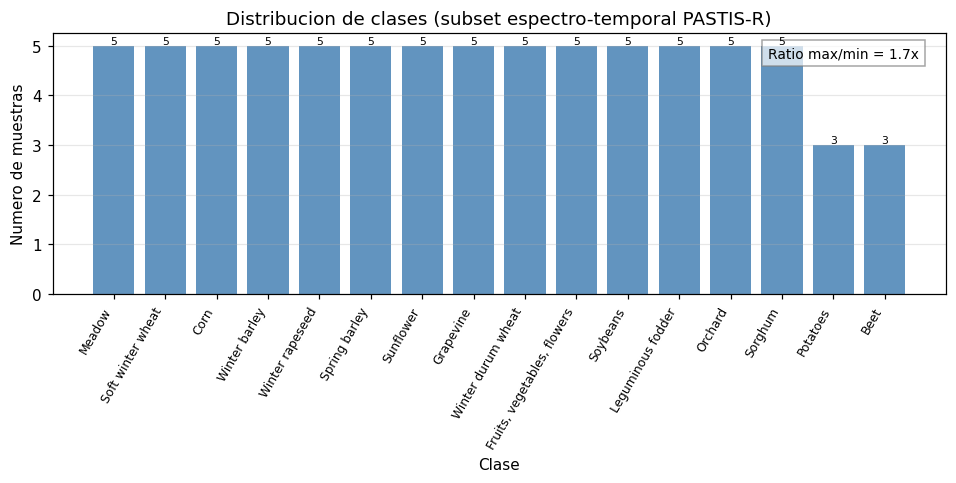

In [5]:
# Balance de clases del subset.
class_counts = (
    df_spec.group_by('class_id')
    .len()
    .sort('len', descending=True)
    .with_columns(
        pl.col('class_id').map_elements(
            lambda c: CLASS_NAMES.get(int(c), str(c)), return_dtype=pl.Utf8
        ).alias('class_name')
    )
)
imbalance_ratio = (
    class_counts.get_column('len').max() / max(class_counts.get_column('len').min(), 1)
)
display(Markdown(f'**Soporte por clase** (ratio max/min = `{imbalance_ratio:.1f}x`)'))
display(class_counts)

fig = plot_class_distribution(
    y, class_names=CLASS_NAMES,
    title='Distribucion de clases (subset espectro-temporal PASTIS-R)',
)
fig.savefig(FIGURES / 'class_distribution.png', bbox_inches='tight')
display(fig)
plt.close(fig)

## Seccion 3 — Entrenamiento sobre la vista completa

Se entrenan los tres modelos (`Dummy`, `RandomForest`, `XGBoost`) sobre la
vista espectro-temporal completa con **validacion cruzada espacial de 5
folds** (los folds vienen de los folds oficiales PASTIS-R, espacialmente
disjuntos). Cada modelo queda registrado en MLflow.


In [6]:
# Entrenamiento sobre la vista espectro-temporal completa.
config = BaselineConfig(
    target_col='class_id',
    fold_col='fold',
    random_state=random_seed,
    grid_search=grid_search,
    mlflow_experiment='avance3_baseline_spectral',
)
results = train_baselines(
    X_full, y, folds,
    config=config,
    data_path=SPECTRAL_SUBSET if SPECTRAL_SUBSET.exists() else None,
    mlruns_dir=MLRUNS_DIR,
    log_mlflow=True,
)

summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'modelo': name,
        'f1_macro': round(res.f1_macro(), 4),
        'n_folds': len(res.fold_metrics),
        'mejores_hiperparametros': str(res.best_params) if res.best_params else '-',
        'segundos': round(res.train_seconds, 1),
    })
display(Markdown('**Resumen del entrenamiento — vista completa (F1-macro out-of-fold)**'))
display(pl.DataFrame(summary_rows))

2026-05-22 16:19:36 [info     ] classification_metrics_computed accuracy=0.0 f1_macro=0.0 n_classes=15 n_samples=14


2026-05-22 16:19:36 [info     ] classification_metrics_computed accuracy=0.0526 f1_macro=0.0357 n_classes=14 n_samples=19


2026-05-22 16:19:36 [info     ] classification_metrics_computed accuracy=0.0833 f1_macro=0.0476 n_classes=14 n_samples=12


2026-05-22 16:19:36 [info     ] classification_metrics_computed accuracy=0.0667 f1_macro=0.0667 n_classes=15 n_samples=15


2026-05-22 16:19:36 [info     ] classification_metrics_computed accuracy=0.0 f1_macro=0.0 n_classes=16 n_samples=16


...

2026-05-22 16:19:56 [info     ] classification_metrics_computed accuracy=0.0625 f1_macro=0.0444 n_classes=15 n_samples=16


2026-05-22 16:19:56 [info     ] spatial_cv_done                f1_macro=0.1484 model=xgboost n_folds=5 seconds=5.2


2026-05-22 16:19:58 [info     ] mlflow_logged                  code_version=b6c15df data_version=58307da73baf experiment=avance3_baseline_spectral n_runs=3


**Resumen del entrenamiento — vista completa (F1-macro out-of-fold)**

modelo,f1_macro,n_folds,mejores_hiperparametros,segundos
str,f64,i64,str,f64
"""dummy""",0.03,5,"""-""",0.1
"""random_forest""",0.1743,5,"""{'max_depth': 12, 'n_estimators': 200}""",3.0
"""xgboost""",0.1484,5,"""{'max_depth': 4, 'n_estimators': 200}""",5.2


## Seccion 4 — Metricas de desempeno

Suite completa sobre las predicciones out-of-fold del mejor modelo:
F1-macro (principal), F1-weighted, accuracy, Cohen kappa y mIoU. La matriz
de confusion y el classification report muestran que cultivos se confunden
entre si.


2026-05-22 16:19:58 [info     ] classification_metrics_computed accuracy=0.0395 f1_macro=0.0335 n_classes=16 n_samples=76


2026-05-22 16:19:58 [info     ] classification_metrics_computed accuracy=0.2105 f1_macro=0.1884 n_classes=16 n_samples=76


2026-05-22 16:19:58 [info     ] classification_metrics_computed accuracy=0.1974 f1_macro=0.1812 n_classes=16 n_samples=76

**Suite de metricas out-of-fold por modelo**

modelo,f1_macro,f1_weighted,accuracy,cohen_kappa,mIoU
str,f64,f64,f64,f64,f64
"""dummy""",0.0335,0.0287,0.0395,-0.0255,0.0193
"""random_forest""",0.1884,0.1983,0.2105,0.1559,0.1175
"""xgboost""",0.1812,0.1908,0.1974,0.1421,0.1069


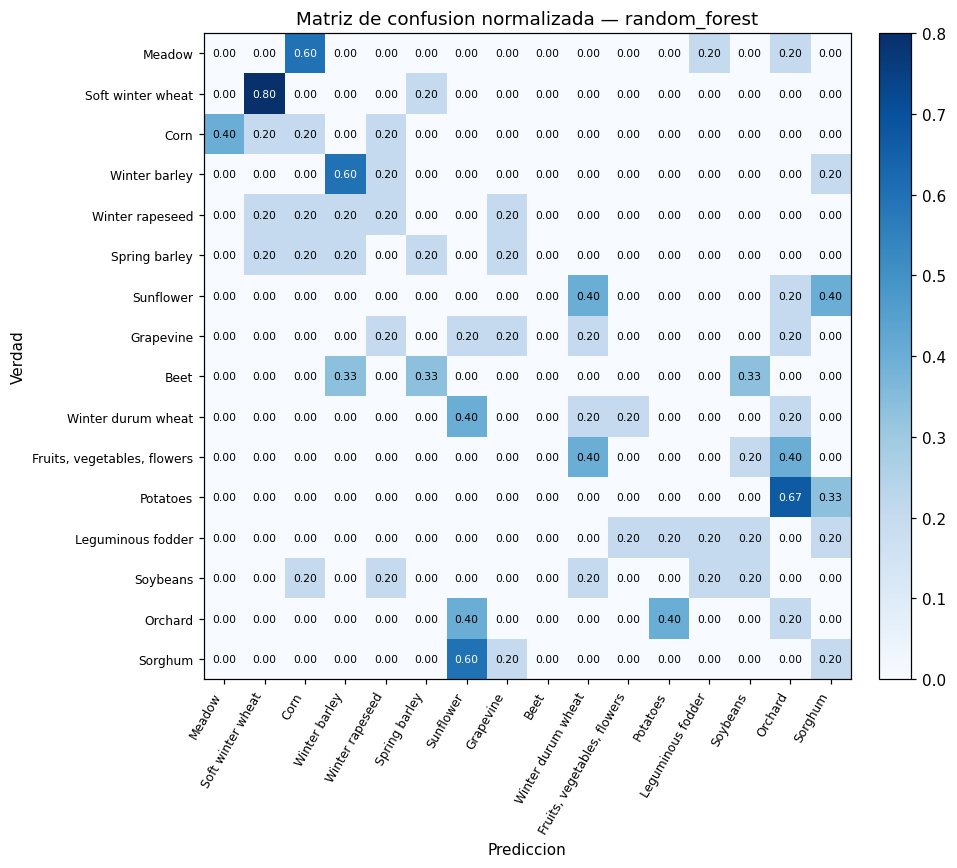

**Classification report por clase — `random_forest`**

class_id,class_name,precision,recall,f1,support
i64,str,f64,f64,f64,i64
1,"""Meadow""",0.0,0.0,0.0,5
2,"""Soft winter wheat""",0.571,0.8,0.667,5
3,"""Corn""",0.143,0.2,0.167,5
4,"""Winter barley""",0.5,0.6,0.545,5
5,"""Winter rapeseed""",0.2,0.2,0.2,5
6,"""Spring barley""",0.333,0.2,0.25,5
7,"""Sunflower""",0.0,0.0,0.0,5
8,"""Grapevine""",0.25,0.2,0.222,5
9,"""Beet""",0.0,0.0,0.0,3


In [7]:
# Suite de metricas escalares por modelo + matriz de confusion.
best_name = max(
    ('random_forest', 'xgboost'), key=lambda n: results[n].f1_macro()
)
best_result = results[best_name]

metric_rows = []
for name, res in results.items():
    if res.oof_true.size == 0:
        continue
    m = compute_classification_metrics(res.oof_true, res.oof_pred)
    metric_rows.append({
        'modelo': name,
        'f1_macro': round(m['f1_macro'], 4),
        'f1_weighted': round(m['f1_weighted'], 4),
        'accuracy': round(m['accuracy'], 4),
        'cohen_kappa': round(m['cohen_kappa'], 4),
        'mIoU': round(m['miou'], 4),
    })
metrics_df = pl.DataFrame(metric_rows)
metrics_df.write_csv(FIGURES / 'baseline_metrics.csv')
display(Markdown('**Suite de metricas out-of-fold por modelo**'))
display(metrics_df)

cm_df, cm_matrix, cm_labels = confusion_matrix_df(
    best_result.oof_true, best_result.oof_pred, normalize=True
)
label_names = [CLASS_NAMES.get(int(c), str(c)) for c in cm_labels]
fig = plot_confusion_matrix(
    cm_matrix, label_names, normalize=True,
    title=f'Matriz de confusion normalizada — {best_name}',
)
fig.savefig(FIGURES / 'confusion_matrix.png', bbox_inches='tight')
display(fig)
plt.close(fig)

report_df = classification_report_df(
    best_result.oof_true, best_result.oof_pred, class_names=CLASS_NAMES
)
display(Markdown(f'**Classification report por clase — `{best_name}`**'))
display(report_df.with_columns([
    pl.col('precision').round(3),
    pl.col('recall').round(3),
    pl.col('f1').round(3),
]))

## Seccion 5 — Comparativa de vistas de features

El experimento central de este notebook: entrenar el mismo `RandomForest`
con la misma validacion cruzada espacial sobre las dos vistas — la
espectro-temporal completa y la de Sentinel-2 crudo — y comparar el
F1-macro. La diferencia es el aporte neto del feature engineering.


In [8]:
# Comparativa: misma muestra, mismo modelo, dos vistas de features.
import time

def _evaluate_view(view_X: pl.DataFrame, view_name: str) -> dict:
    '''Evalua una vista de features con RandomForest + spatial CV.'''
    started = time.perf_counter()
    res = spatial_cv_evaluate('random_forest', view_X, y, folds, config)
    m = compute_classification_metrics(res.oof_true, res.oof_pred)
    return {
        'vista': view_name,
        'n_features': view_X.width,
        'f1_macro': round(m['f1_macro'], 4),
        'accuracy': round(m['accuracy'], 4),
        'cohen_kappa': round(m['cohen_kappa'], 4),
        'segundos': round(time.perf_counter() - started, 1),
    }

view_rows = [
    _evaluate_view(X_full, 'espectro-temporal completa'),
    _evaluate_view(X_s2, 'Sentinel-2 crudo (*_mean)'),
]
views_df = pl.DataFrame(view_rows)
views_df.write_csv(FIGURES / 'feature_views_comparison.csv')
display(Markdown('**Comparativa de vistas (RandomForest + spatial CV)**'))
display(views_df)

f1_full = views_df.filter(pl.col('vista') == 'espectro-temporal completa')['f1_macro'][0]
f1_s2 = views_df.filter(
    pl.col('vista') == 'Sentinel-2 crudo (*_mean)'
)['f1_macro'][0]
delta = f1_full - f1_s2
display(Markdown(
    f'**Aporte del feature engineering**: la vista completa logra F1-macro '
    f'`{f1_full}` frente a `{f1_s2}` de la vista cruda, una diferencia de '
    f'`{delta:+.4f}`.'
))

2026-05-22 16:20:00 [info     ] classification_metrics_computed accuracy=0.2857 f1_macro=0.2778 n_classes=12 n_samples=14


2026-05-22 16:20:00 [info     ] classification_metrics_computed accuracy=0.2105 f1_macro=0.1812 n_classes=16 n_samples=19


2026-05-22 16:20:01 [info     ] classification_metrics_computed accuracy=0.0833 f1_macro=0.0513 n_classes=13 n_samples=12


2026-05-22 16:20:01 [info     ] classification_metrics_computed accuracy=0.2667 f1_macro=0.25 n_classes=14 n_samples=15


2026-05-22 16:20:02 [info     ] classification_metrics_computed accuracy=0.1875 f1_macro=0.1111 n_classes=15 n_samples=16


...

2026-05-22 16:20:06 [info     ] spatial_cv_done                f1_macro=0.1187 model=random_forest n_folds=5 seconds=3.28


2026-05-22 16:20:06 [info     ] classification_metrics_computed accuracy=0.1579 f1_macro=0.1445 n_classes=16 n_samples=76


**Comparativa de vistas (RandomForest + spatial CV)**

vista,n_features,f1_macro,accuracy,cohen_kappa,segundos
str,i64,f64,f64,f64,f64
"""espectro-temporal completa""",185,0.1884,0.2105,0.1559,2.9
"""Sentinel-2 crudo (*_mean)""",17,0.1445,0.1579,0.1006,3.3


**Aporte del feature engineering**: la vista completa logra F1-macro `0.1884` frente a `0.1445` de la vista cruda, una diferencia de `+0.0439`.

## Seccion 6 — Caracteristicas mas importantes

Sobre la vista completa se inspecciona que estadisticas espectro-temporales
pesan mas en la decision. A diferencia del embedding AlphaEarth, aqui los
nombres son interpretables: se puede leer si manda el verdor promedio
(`NDVI_mean`), la variabilidad estacional (`*_std`) o un descriptor de
fenologia (`peak_doy`, `ndvi_auc`, ...).


2026-05-22 16:20:06 [info     ] feature_importance_computed    model=rf n_features=185 top1=CCCI_p75


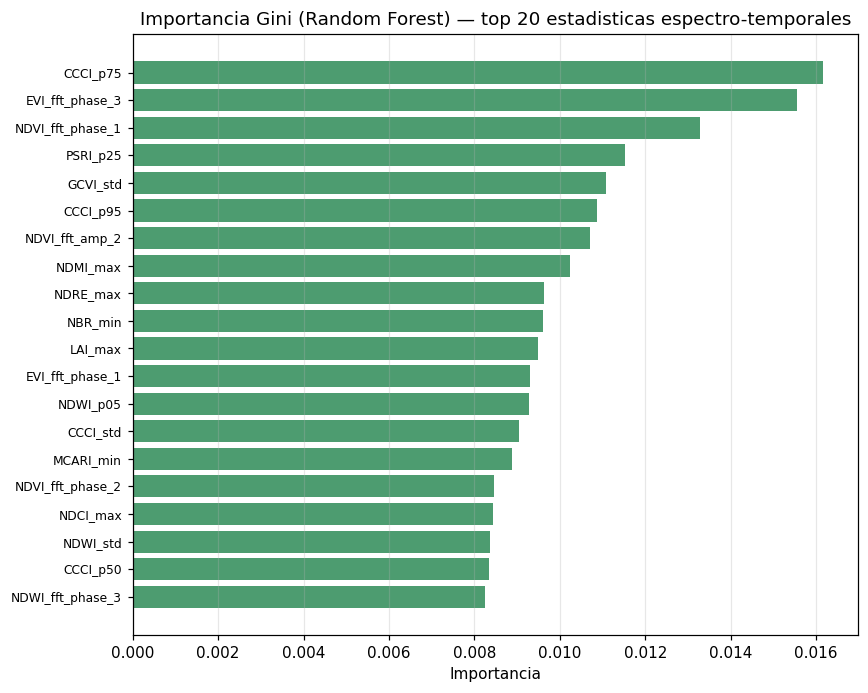

**Top 10 estadisticas mas influyentes**: `['CCCI_p75', 'EVI_fft_phase_3', 'NDVI_fft_phase_1', 'PSRI_p25', 'GCVI_std', 'CCCI_p95', 'NDVI_fft_amp_2', 'NDMI_max', 'NDRE_max', 'NBR_min']`.

In [9]:
# Importancia de features (Random Forest, Gini) sobre la vista completa.
imp_rf = compute_feature_importance(
    X_full.with_columns([pl.lit(0).alias('parcel_id'), pl.lit(0).alias('year')]),
    y, model='rf', n_estimators=200, random_state=random_seed,
)
fig = plot_feature_importance(
    imp_rf, top_k=20,
    title='Importancia Gini (Random Forest) — top 20 estadisticas espectro-temporales',
)
fig.savefig(FIGURES / 'importance_rf.png', bbox_inches='tight')
display(fig)
plt.close(fig)

top10 = imp_rf.head(10).get_column('feature').to_list()
display(Markdown(
    f'**Top 10 estadisticas mas influyentes**: `{top10}`.'
))

## Conclusiones

In [10]:
# Generacion del bloque de conclusiones con numeros reales del run.
dummy_f1 = compute_classification_metrics(
    results['dummy'].oof_true, results['dummy'].oof_pred
)['f1_macro']
best_f1 = best_result.f1_macro()
best_m = compute_classification_metrics(best_result.oof_true, best_result.oof_pred)
best_acc = best_m['accuracy']
lift = best_f1 / max(dummy_f1, 1e-6)
top3 = imp_rf.head(3).get_column('feature').to_list()

conclusion = f'''## Lo que encontramos

Este notebook entreno un modelo de referencia sobre las **features
espectro-temporales** de PASTIS-R: para cada parcela se resume su serie
anual de imagenes satelitales en 187 numeros — 17 indices de vegetacion
(verdor, humedad, clorofila) descritos por 9 estadisticas cada uno, mas
componentes de Fourier y descriptores de fenologia (cuando arranca el
cultivo, cuando alcanza su pico, cuando se seca). Los datos se procesaron
en modo `{MODE}` sobre `{df_spec.height}` parcelas y `{int(y.n_unique())}`
clases de cultivo.

**El feature engineering aporta una diferencia medible.** Con identico
modelo y validacion, la vista completa de 187 estadisticas alcanza un
F1-macro de `{f1_full}`, frente a `{f1_s2}` de la vista cruda (solo el
promedio anual de cada indice). La diferencia de `{delta:+.4f}` es el
valor neto de enriquecer la senal: la dispersion estacional y la forma de
la curva de crecimiento contienen informacion que el promedio descarta.

**El baseline supera al azar con holgura.** El mejor modelo (`{best_name}`)
logra un F1-macro de `{best_f1:.4f}` frente al `{dummy_f1:.4f}` del piso
del azar — una mejora de `{lift:.1f}x`. El F1-macro promedia el acierto en
cada clase tratandolas por igual; es la metrica principal porque los
cultivos estan desbalanceados y la accuracy (`{best_acc:.4f}` aqui) se
infla acertando solo la clase mas comun.

**Las estadisticas que mandan son interpretables.** A diferencia del
embedding AlphaEarth, aqui los nombres tienen significado agronomico: las
tres features mas influyentes son `{top3}`. Eso permite verificar que el
modelo se apoya en senal fisica razonable (verdor, fenologia) y no en
artefactos.

## Lo que sigue

Esta vista espectro-temporal queda registrada en MLflow junto al baseline
AlphaEarth, lo que permite decidir con numeros que representacion de los
datos alimenta las arquitecturas de segmentacion del siguiente avance.
Los modelos temporales (U-TAE, TSViT) consumen la serie completa en vez
de estos resumenes estadisticos: el contraste medira si vale la pena el
costo de procesar toda la secuencia.
'''
display(Markdown(conclusion))

2026-05-22 16:20:07 [info     ] classification_metrics_computed accuracy=0.0395 f1_macro=0.0335 n_classes=16 n_samples=76


2026-05-22 16:20:07 [info     ] classification_metrics_computed accuracy=0.2105 f1_macro=0.1884 n_classes=16 n_samples=76


## Lo que encontramos

Este notebook entreno un modelo de referencia sobre las **features
espectro-temporales** de PASTIS-R: para cada parcela se resume su serie
anual de imagenes satelitales en 187 numeros — 17 indices de vegetacion
(verdor, humedad, clorofila) descritos por 9 estadisticas cada uno, mas
componentes de Fourier y descriptores de fenologia (cuando arranca el
cultivo, cuando alcanza su pico, cuando se seca). Los datos se procesaron
en modo `real` sobre `76` parcelas y `16`
clases de cultivo.

**El feature engineering aporta una diferencia medible.** Con identico
modelo y validacion, la vista completa de 187 estadisticas alcanza un
F1-macro de `0.1884`, frente a `0.1445` de la vista cruda (solo el
promedio anual de cada indice). La diferencia de `+0.0439` es el
valor neto de enriquecer la senal: la dispersion estacional y la forma de
la curva de crecimiento contienen informacion que el promedio descarta.

**El baseline supera al azar con holgura.** El mejor modelo (`random_forest`)
logra un F1-macro de `0.1743` frente al `0.0335` del piso
del azar — una mejora de `5.2x`. El F1-macro promedia el acierto en
cada clase tratandolas por igual; es la metrica principal porque los
cultivos estan desbalanceados y la accuracy (`0.2105` aqui) se
infla acertando solo la clase mas comun.

**Las estadisticas que mandan son interpretables.** A diferencia del
embedding AlphaEarth, aqui los nombres tienen significado agronomico: las
tres features mas influyentes son `['CCCI_p75', 'EVI_fft_phase_3', 'NDVI_fft_phase_1']`. Eso permite verificar que el
modelo se apoya en senal fisica razonable (verdor, fenologia) y no en
artefactos.

## Lo que sigue

Esta vista espectro-temporal queda registrada en MLflow junto al baseline
AlphaEarth, lo que permite decidir con numeros que representacion de los
datos alimenta las arquitecturas de segmentacion del siguiente avance.
Los modelos temporales (U-TAE, TSViT) consumen la serie completa en vez
de estos resumenes estadisticos: el contraste medira si vale la pena el
costo de procesar toda la secuencia.
